In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv("/content/IMDB Dataset.csv")

In [5]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [11]:
df.shape

(50000, 2)

In [12]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [13]:
df.isnull().sum()

,0
review,0
sentiment,0


In [14]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


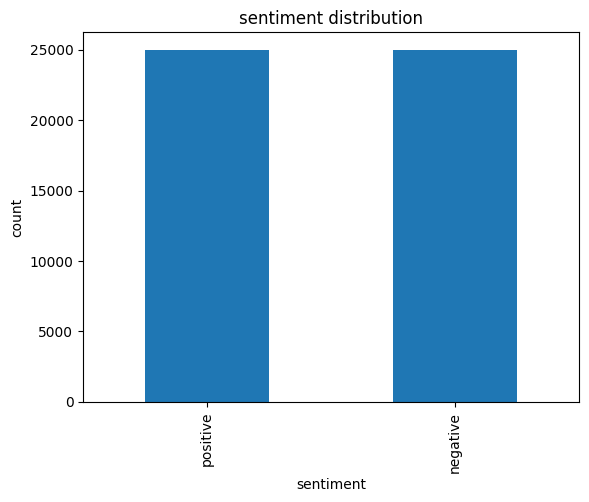

In [15]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("sentiment distribution")
plt.xlabel("sentiment")
plt.ylabel("count")
plt.show()

In [16]:
df['review']= df['review'].str.lower()

In [17]:
df['review'][0]

"one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.<br /><br />the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.<br /><br />it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />i would say the main appeal of the show is due to the fa

In [18]:
import re
def clean_text(text):
  text = re.sub(r'[^a-zA-Z\s]','',text)
  return text
df['review']=df['review'].apply(clean_text)

In [19]:
df['review'][0]

'one of the other reviewers has mentioned that after watching just  oz episode youll be hooked they are right as this is exactly what happened with mebr br the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordbr br it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awaybr br i would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare for

In [20]:
import re
def clean(text):
  text=re.sub(r'<.*?>','',text)
  text=text.lower()
  text=re.sub(r'[^a-zA-Z\s]','',text)
  text = re.sub(r'\bbr\b', '', text)
  return text

df['review']=df['review'].apply(clean)

In [21]:
df['review'][1]

'a wonderful little production   the filming technique is very unassuming very oldtimebbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece   the actors are extremely well chosen michael sheen not only has got all the polari but he has all the voices down pat too you can truly see the seamless editing guided by the references to williams diary entries not only is it well worth the watching but it is a terrificly written and performed piece a masterful production about one of the great masters of comedy and his life   the realism really comes home with the little things the fantasy of the guard which rather than use the traditional dream techniques remains solid then disappears it plays on our knowledge and our senses particularly with the scenes concerning orton and halliwell and the sets particularly of their flat with halliwells murals decorating every surface are terribly well done'

In [22]:
df.shape

(50000, 2)

In [23]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [24]:
stop_words= set(stopwords.words('english'))

In [25]:
print(stop_words)

{'do', 'themselves', 'too', 'very', 'both', 'ours', 'only', 'by', "she's", 'further', "we're", "didn't", 'we', 'your', "he'll", 'me', "we've", "it'd", 'all', "she'll", 'some', 'below', 'here', "you'll", 'yours', "couldn't", "they've", 'above', 'against', 'his', 'other', 'yourselves', "she'd", 'couldn', 'off', 'm', "we'll", 'him', 'such', 'does', 'which', 'herself', 'over', "we'd", 'an', 'have', 'same', 'myself', 'as', 'from', 't', 'under', 'wasn', 'our', 'how', 'this', 'until', "doesn't", "they'll", 'wouldn', 'they', 'mightn', 'weren', 'was', 'needn', 'now', 'will', 'are', 'll', 'once', 'had', 'be', 'because', 'i', 'through', 'not', 'or', "wasn't", 'didn', 'can', "they're", 'before', "aren't", 'own', 'so', "it'll", 'its', 'for', 'hers', 'mustn', 'itself', 'their', 'while', 'don', 'were', 'again', 'did', "it's", 'hasn', 'nor', "mightn't", 'to', "that'll", 'after', 'then', 'is', "he'd", "shan't", "you're", 'ourselves', 'when', 'at', 'has', 'no', 'it', 'o', 'these', 'am', "i've", 'haven',

In [26]:
def remove(text):
  words=text.split()
  filtered=[word for word in words if word not in stop_words]
  return " ".join(filtered)


In [27]:
df['review'] = df['review'].apply(remove)

In [28]:
df

,review,sentiment
0,one reviewers mentioned watching oz episode yo...,positive
1,wonderful little production filming technique ...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically theres family little boy jake thinks...,negative
4,petter matteis love time money visually stunni...,positive
...,...,...
49995,thought movie right good job wasnt creative or...,positive
49996,bad plot bad dialogue bad acting idiotic direc...,negative
49997,catholic taught parochial elementary schools n...,negative
49998,im going disagree previous comment side maltin...,negative


In [29]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [30]:
from nltk.tokenize import word_tokenize

In [31]:
tokens = word_tokenize(df['review'][0])
print(tokens)

['one', 'reviewers', 'mentioned', 'watching', 'oz', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'mebr', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scenes', 'violence', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'hearted', 'timid', 'show', 'pulls', 'punches', 'regards', 'drugs', 'sex', 'violence', 'hardcore', 'classic', 'use', 'wordbr', 'called', 'oz', 'nickname', 'given', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'focuses', 'mainly', 'emerald', 'city', 'experimental', 'section', 'prison', 'cells', 'glass', 'fronts', 'face', 'inwards', 'privacy', 'high', 'agenda', 'em', 'city', 'home', 'manyaryans', 'muslims', 'gangstas', 'latinos', 'christians', 'italians', 'irish', 'moreso', 'scuffles', 'death', 'stares', 'dodgy', 'dealings', 'shady', 'agreements', 'never', 'far', 'awaybr', 'would', 'say', 'main', 'appeal', 'show', 'due', 'fact', 'goes', 'shows', 'wouldnt', 'dare', 'forget', 'pretty', 'pictures', 'painted', 'mainstream'

In [32]:
df['review'][0]

'one reviewers mentioned watching oz episode youll hooked right exactly happened mebr first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use wordbr called oz nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inwards privacy high agenda em city home manyaryans muslims gangstas latinos christians italians irish moreso scuffles death stares dodgy dealings shady agreements never far awaybr would say main appeal show due fact goes shows wouldnt dare forget pretty pictures painted mainstream audiences forget charm forget romanceoz doesnt mess around first episode ever saw struck nasty surreal couldnt say ready watched developed taste oz got accustomed high levels graphic violence violence injustice crooked guards wholl sold nickel inmates wholl kill order get away well mannered middle cl

In [33]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

In [34]:
def stem_text(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

In [35]:
df['review'] = df['review'].apply(stem_text)

In [36]:
df['review'][0]

'one review mention watch oz episod youll hook right exactli happen mebr first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use wordbr call oz nicknam given oswald maximum secur state penitentari focus mainli emerald citi experiment section prison cell glass front face inward privaci high agenda em citi home manyaryan muslim gangsta latino christian italian irish moreso scuffl death stare dodgi deal shadi agreement never far awaybr would say main appeal show due fact goe show wouldnt dare forget pretti pictur paint mainstream audienc forget charm forget romanceoz doesnt mess around first episod ever saw struck nasti surreal couldnt say readi watch develop tast oz got accustom high level graphic violenc violenc injustic crook guard wholl sold nickel inmat wholl kill order get away well manner middl class inmat turn prison bitch due lack street skill prison experi watch oz may becom co

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

In [43]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [44]:
df['review']

,review
0,one review mention watch oz episod youll hook ...
1,wonder littl product film techniqu unassum old...
2,thought wonder way spend time hot summer weeke...
3,basic there famili littl boy jake think there ...
4,petter mattei love time money visual stun film...
...,...
49995,thought movi right good job wasnt creativ orig...
49996,bad plot bad dialogu bad act idiot direct anno...
49997,cathol taught parochi elementari school nun ta...
49998,im go disagre previou comment side maltin one ...


In [45]:
print(X.shape)

(50000, 608554)


In [46]:
from sklearn.model_selection import train_test_split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [48]:
print(X_train.shape)
print(X_test.shape)

(40000, 608554)
(10000, 608554)


In [49]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    C=5,
    max_iter=3000,
    solver='liblinear'
)

In [50]:
model.fit(X_train, y_train)

LogisticRegression(C=5, max_iter=3000, solver='liblinear')

In [51]:
y_pred = model.predict(X_test)

In [52]:
from sklearn.metrics import accuracy_score

In [53]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100)

Accuracy: 90.56


In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X = vectorizer.fit_transform(df['review'])

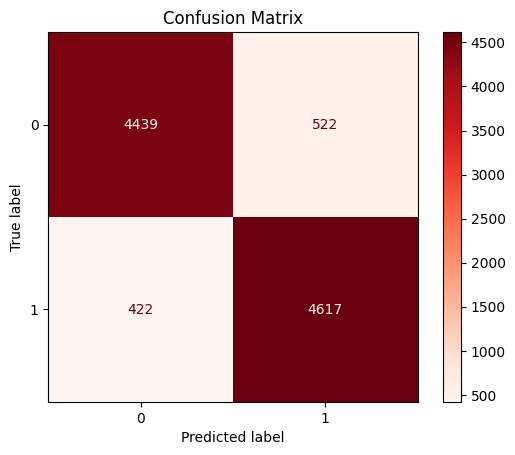

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Reds')
plt.title("Confusion Matrix")
plt.show()

In [92]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      4961
    positive       0.89      0.92      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [97]:
review = ["Bad Movie. Waste of time."]

review_vector = vectorizer.transform(review)

prediction = model.predict(review_vector)

print(prediction)

['negative']


In [98]:
review = ["Good movie, Amazing acting"]

review_vector = vectorizer.transform(review)

prediction = model.predict(review_vector)

print(prediction)

['positive']


In [61]:
import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!
